# Global biofuels consumption: modeling and country ranking

Predicting biofuels consumption (biodiesel + ethanol) by country,
comparing several ML algorithms, applying hyperparameter tuning with
two different approaches, and translating the results into business
metrics (CAGR, penetration, regional ranking).

**Author:** Virginia Galván, PhD — [LinkedIn](https://www.linkedin.com/in/virgina-galvan-390ba233b/)

## Table of contents

1. [Context and business question](#1-context)
2. [Data](#2-data)
3. [EDA](#3-eda) — full detail in `notebooks/01_eda.ipynb`
4. [Modeling and algorithm comparison](#4-modeling) — full detail in `notebooks/02_modeling.ipynb`
5. [Business KPIs and ranking](#5-kpis) — full detail in `notebooks/03_business_kpis.ipynb`
6. [Results](#6-results)
7. [How to run this project](#7-how-to-run)

## 1. Context and business question <a id="1-context"></a>

Biofuels consumption (biodiesel + ethanol) grew very unevenly across
countries over the last two decades, driven by blending mandates,
feedstock availability, and the size of each country's liquid-fuels
mix. The business question: **given a country's history and
macro/energy context, how much will it consume next year, and which
countries have the most growth potential?**

It's the kind of question that, at an agribusiness, energy, or
commodity trading company, feeds decisions about where to prioritize
markets.

## 2. Data <a id="2-data"></a>

Source: [Our World in Data - Global Energy dataset](https://github.com/owid/energy-data)
(Energy Institute, Ember, Maddison Project; see `data/raw/README.md`
for column-level detail). Country-year panel 2000-2024, 107 countries with reported
biofuels consumption data (including zero consumption, which is
real information). The source reports 108 countries; one
(Netherlands Antilles, a dissolved political entity with no
current continent classification) is excluded, since continent
is one of the model's features.

In [1]:
import sys
sys.path.insert(0, ".")

import pandas as pd
from IPython.display import Image
from src.data import load_clean_panel

pd.set_option("display.max_columns", None)
df = load_clean_panel()
print(f"{len(df)} rows, {df['country'].nunique()} countries, {df['year'].min()}-{df['year'].max()}")
df.head()

2608 rows, 108 countries, 2000-2024


,country,year,iso_code,population,gdp,biofuel_cons_per_capita,biofuel_consumption,biofuel_electricity,biofuel_share_energy,electricity_generation,energy_per_capita,oil_consumption,renewables_share_energy
0,Algeria,2000,DZA,30903894.0,2.085542e+11,0.0,0.0,0.0,0.0,25.40,9705.756,103.132,0.050
1,Algeria,2001,DZA,31331226.0,2.234203e+11,0.0,0.0,0.0,0.0,26.62,9920.229,106.775,0.061
2,Algeria,2002,DZA,31750832.0,2.453609e+11,0.0,0.0,0.0,0.0,27.65,10139.907,118.397,0.049
3,Algeria,2003,DZA,32175813.0,2.735686e+11,0.0,0.0,0.0,0.0,29.57,10471.285,123.174,0.214
4,Algeria,2004,DZA,32628286.0,2.967736e+11,0.0,0.0,0.0,0.0,31.25,10720.079,128.747,0.194


## 3. EDA <a id="3-eda"></a>

See `notebooks/01_eda.ipynb` for the full analysis. The target
distribution is strongly long-tailed: most countries consume little
or nothing, and a small group concentrates most of the world volume.

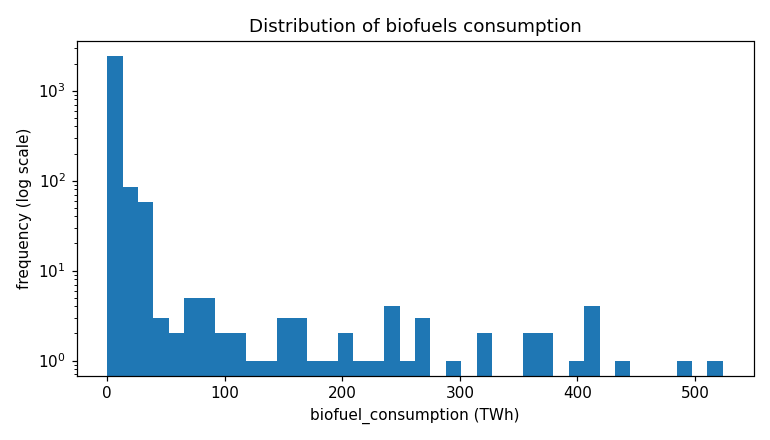

In [2]:
Image(filename="reports/figures/target_distribution.png")

5 countries account for ~80% of cumulative world consumption, and
consumption correlates much more with the size of a country's energy
mix (`oil_consumption`, r=0.66) than with its wealth per capita
(`gdp_per_capita`, r=0.11).

In [3]:
latest_year = df["year"].max()
(
    df[df["year"] == latest_year]
    .sort_values("biofuel_consumption", ascending=False)
    [["country", "biofuel_consumption", "biofuel_share_energy"]]
    .reset_index(drop=True)
    .head(10)
)

,country,biofuel_consumption,biofuel_share_energy
0,United States,523.642,1.987
1,Brazil,269.880,7.054
2,Indonesia,120.655,4.034
3,India,47.630,0.422
4,China,37.228,0.077
5,France,34.019,1.371
6,Canada,32.977,0.863
7,Germany,30.576,0.968
8,United Kingdom,27.702,1.445
9,Thailand,22.829,1.610


## 4. Modeling and algorithm comparison <a id="4-modeling"></a>

See `notebooks/02_modeling.ipynb` for the full detail: six models
(`DummyRegressor`, Ridge, Random Forest, XGBoost, LightGBM, CatBoost),
temporal cross-validation (expanding window), tuning with a
`RandomizedSearchCV`-style search and Optuna over the winning model,
and interpretability with SHAP.

### Comparison across the six models (before tuning)

In [4]:
comparison = pd.read_csv("data/processed/model_comparison.csv")
comparison

,model,MAE,MAE_CI95,RMSE,R2,R2_CI95,WMAE
0,xgboost,1.14,"[0.89, 1.44]",5.23,0.986,"[0.976, 0.993]",1.63
1,ridge,1.18,"[1.01, 1.36]",3.63,0.993,"[0.990, 0.995]",1.56
2,random_forest,1.21,"[0.93, 1.49]",5.74,0.983,"[0.976, 0.989]",1.80
3,catboost,1.44,"[1.10, 1.88]",7.94,0.967,"[0.940, 0.988]",2.10
4,lightgbm,2.25,"[1.81, 2.72]",9.42,0.955,"[0.939, 0.966]",3.38
5,dummy,11.20,"[9.32, 13.50]",44.62,-0.009,"[-0.016, -0.003]",16.80


### Final comparison, with the winner's tuned metrics

In [5]:
comparison_final = pd.read_csv("data/processed/model_comparison_final.csv")
comparison_final

,model,MAE,MAE_CI95,RMSE,R2,R2_CI95,WMAE
0,Ridge,1.18,"[1.01, 1.36]",3.63,0.993,"[0.990, 0.995]",1.56
1,Random Forest,1.21,"[0.93, 1.49]",5.74,0.983,"[0.976, 0.989]",1.80
2,CatBoost,1.44,"[1.10, 1.88]",7.94,0.967,"[0.940, 0.988]",2.10
3,LightGBM,2.25,"[1.81, 2.72]",9.42,0.955,"[0.939, 0.966]",3.38
4,DummyRegressor (baseline),11.20,"[9.32, 13.50]",44.62,-0.009,"[-0.016, -0.003]",16.80
5,XGBoost (tuned),1.10,"[0.86, 1.37]",5.09,0.986,"[0.978, 0.992]",1.59


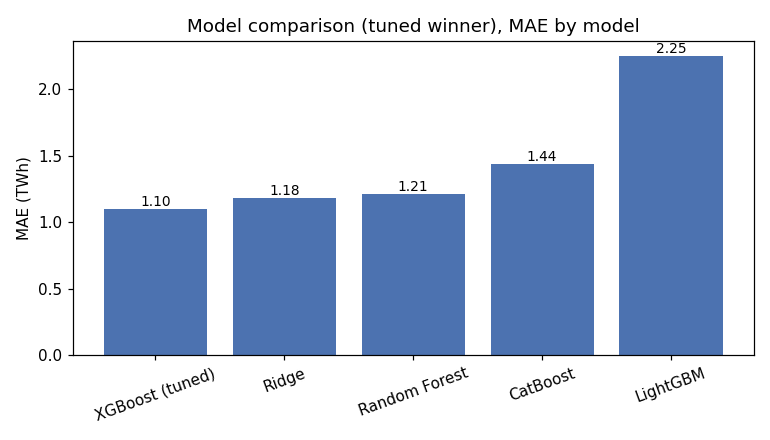

In [6]:
Image(filename="reports/figures/model_comparison.png")

### How well the tuned model fits: actual vs. predicted

Out-of-fold predictions from the temporal cross-validation.

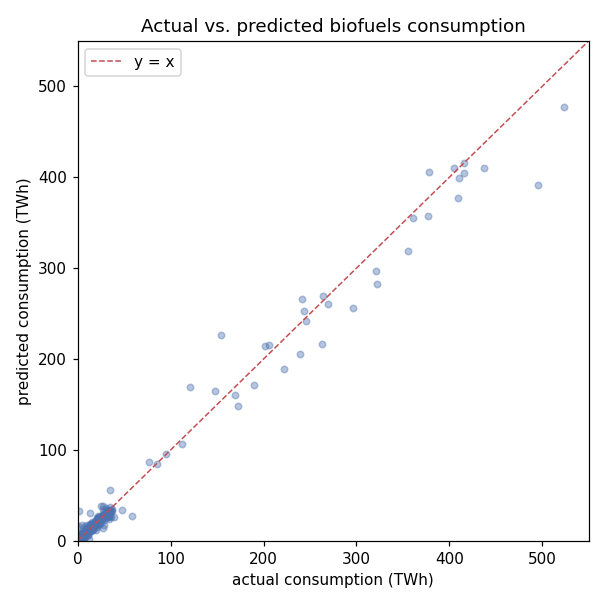

In [7]:
Image(filename="reports/figures/actual_vs_predicted.png")

### Interpretability: what drives the model's predictions (SHAP)

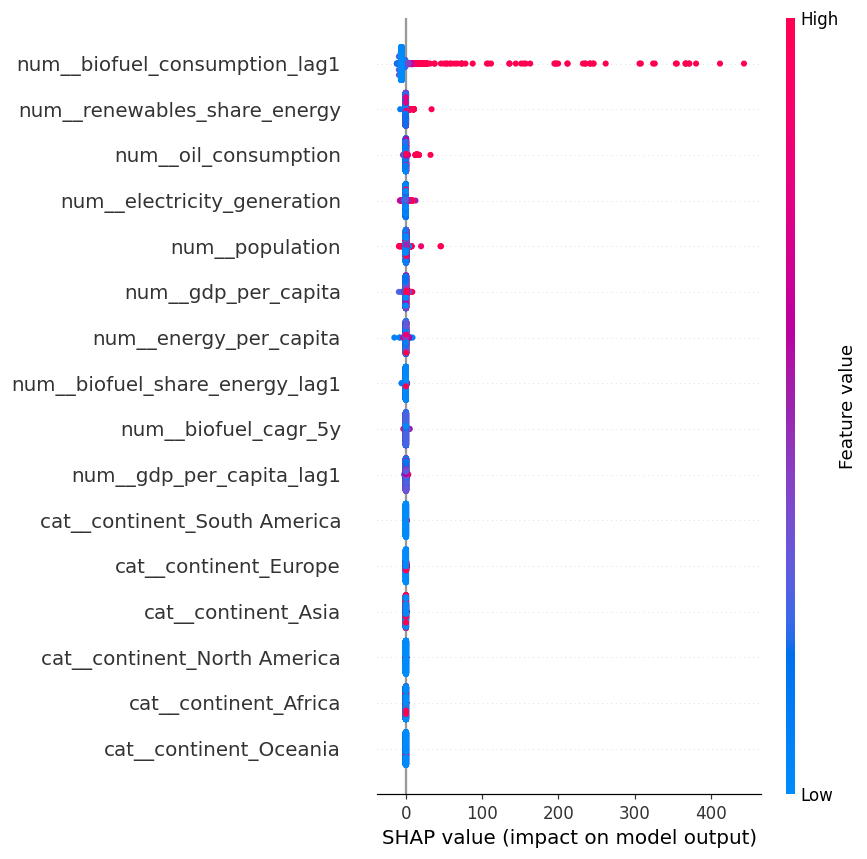

In [8]:
Image(filename="reports/figures/shap_summary.png")

## 5. Business KPIs and ranking <a id="5-kpis"></a>

See `notebooks/03_business_kpis.ipynb`: 5-year CAGR, penetration
(share of primary energy), normalized score and ranking by continent,
and the tables exported to `data/exports/`.

### Top consuming countries

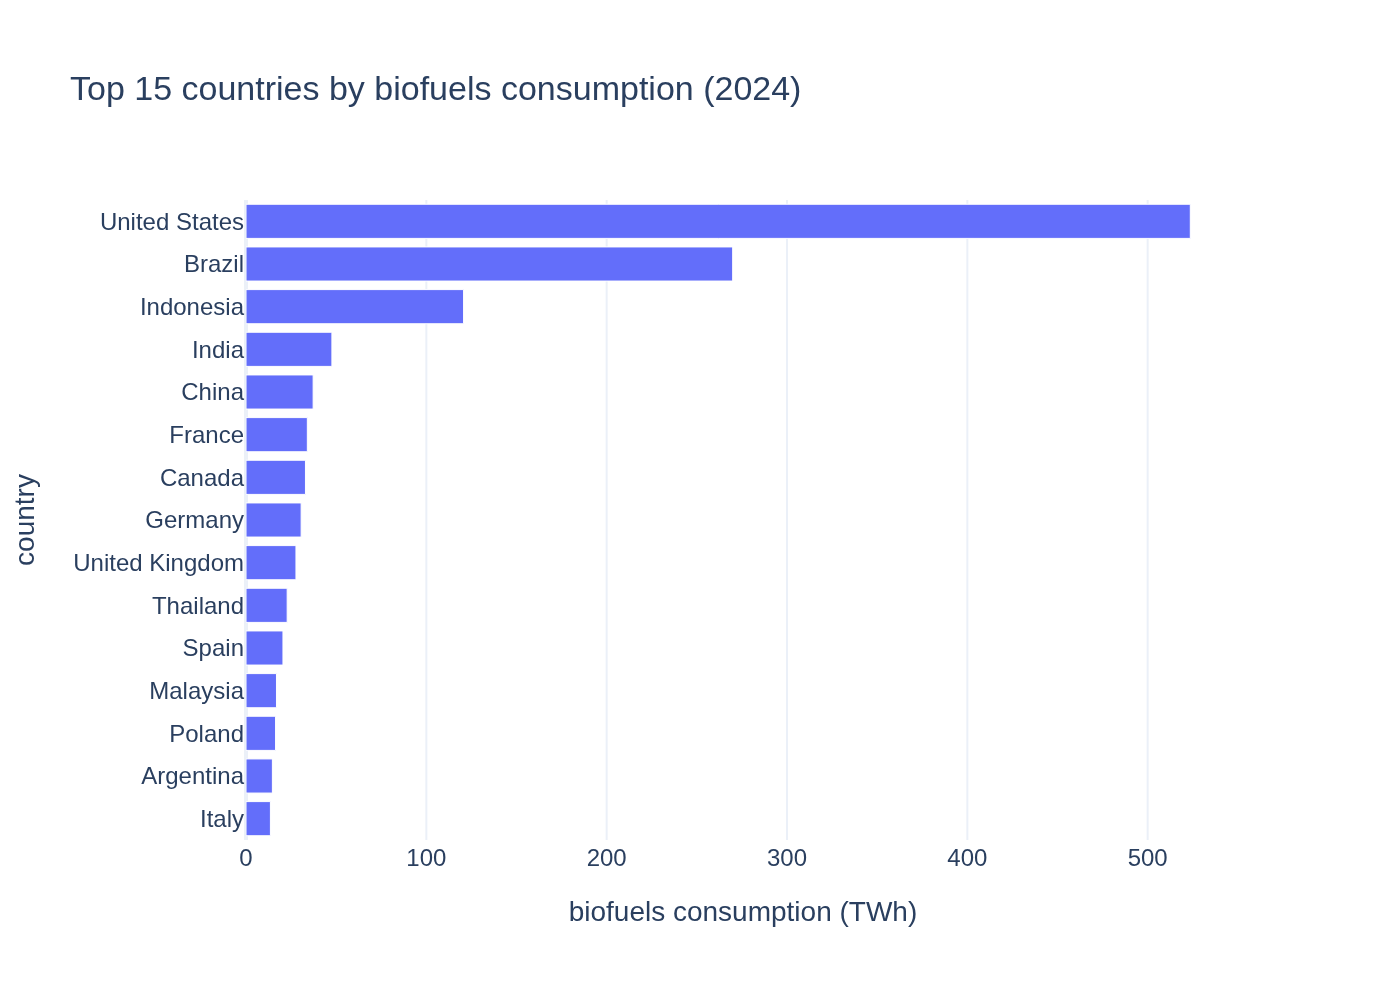

In [9]:
Image(filename="reports/figures/top15_countries.png")

### Growth-potential ranking, leader per continent

In [10]:
ranking = pd.read_csv("data/exports/country_ranking_powerbi.csv")
ranking[ranking["continent_ranking"] == 1].sort_values("continent")

,country,continent,year,biofuel_consumption,biofuel_share_energy,biofuel_cagr_5y,growth_score,continent_ranking
0,Algeria,Africa,2024,0.000,0.000,NaN,0.0,1.0
18,Zimbabwe,Africa,2024,0.000,NaN,NaN,0.0,1.0
17,Zambia,Africa,2024,0.000,NaN,NaN,0.0,1.0
16,Tunisia,Africa,2024,0.000,NaN,NaN,0.0,1.0
15,Sudan,Africa,2024,0.000,NaN,NaN,0.0,1.0
14,South Sudan,Africa,2024,0.000,NaN,NaN,0.0,1.0
13,South Africa,Africa,2024,1.024,0.075,-0.028852,0.0,1.0
12,Nigeria,Africa,2024,0.000,NaN,NaN,0.0,1.0
10,Morocco,Africa,2024,0.000,0.000,NaN,0.0,1.0
11,Mozambique,Africa,2024,0.000,NaN,NaN,0.0,1.0


### Translating the model's error into business terms

What percentage of actual consumption the model's typical error
represents, for the large countries (top-80% of world consumption)
versus the rest.

In [11]:
business_summary = pd.read_csv("data/exports/business_summary_powerbi.csv")
business_summary

,top80_consumer,countries,avg_actual_consumption_TWh,avg_absolute_error_TWh,error_pct_of_consumption
0,other countries,102.0,2.792435,0.553061,19.8057
1,top-80% consumption countries,5.0,140.799640,11.972334,8.5031


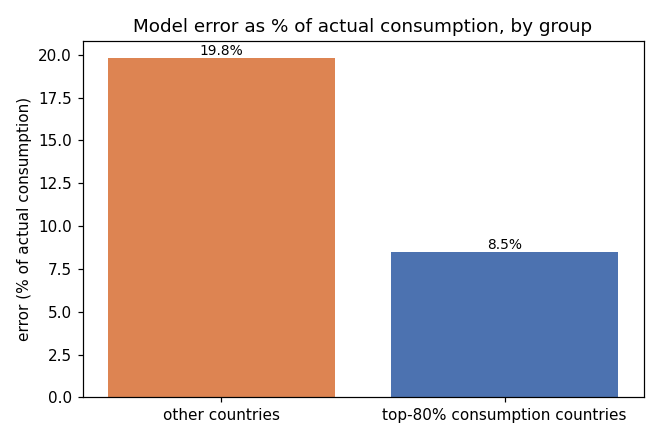

In [12]:
Image(filename="reports/figures/business_error_summary.png")

## 6. Results <a id="6-results"></a>

- XGBoost tuned with Optuna has the best point-estimate MAE (see
  section 4), but its 95% confidence interval overlaps with Ridge's:
  there is no evidence that one is significantly better than the
  other on this dataset.
- The model cuts the error by more than 10x versus the baseline
  (`DummyRegressor`, MAE ~11.2 TWh vs. ~1.1 TWh for the final model).
- The model's error, measured as a % of actual consumption, is
  smaller for large countries (top-80% of consumption, ~8.5%) than
  for the rest (~19.8%) — the model is proportionally less precise
  for countries with near-zero consumption, but the absolute-volume
  impact there is minimal.
- World biofuels consumption in 2024: ~1,360 TWh, led by the United
  States.

## 7. How to run this project <a id="7-how-to-run"></a>

```bash
git clone https://github.com/virginiagalvan/biofuels-market-forecasting-en.git
cd biofuels-market-forecasting-en
python -m venv venv
source venv/bin/activate  # Windows: venv\Scripts\activate
pip install -r requirements.txt
jupyter notebook main.ipynb
```

The notebooks in `notebooks/` are run from that same folder (they use
relative paths `../data`, `../src`, etc.). `data/raw/README.md`
explains how to regenerate `owid_energy_raw.csv` if needed.